## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga de datos

In [2]:
df = pd.read_csv("../../Data/clean_data_24-03-2026.csv", parse_dates=['insert_date','first_review_date','last_review_date'])
df

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,price_missing,reviews 80+
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,(sin contestar),Private room,2,2.0,1.0,...,100.0,100.0,100.0,False,75.0,spain,Malaga,2018-07-31,False,True
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,C�rmenes,Latina,Private room,1,1.0,1.0,...,100.0,80.0,90.0,False,52.0,spain,Madrid,2020-01-10,False,True
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2.0,...,100.0,100.0,100.0,True,142.0,spain,Sevilla,2019-07-29,False,True
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,l'Antiga Esquerra de l'Eixample,Eixample,Private room,2,2.0,1.0,...,100.0,100.0,90.0,True,306.0,spain,Barcelona,2020-01-10,False,True
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,(sin contestar),Private room,5,1.0,2.0,...,100.0,100.0,100.0,False,39.0,spain,Girona,2019-02-19,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9645,47710189,Beautiful house in the centre in Santa Cristin...,Beautiful house in the center of Santa Cristin...,263841355,Santa Cristina d'Aro,(sin contestar),Entire home/apt,8,2.0,4.0,...,NaN,NaN,NaN,True,NaN,spain,Girona,2021-01-31,False,NaN
9646,47752964,Costa Brava - Palafrugell - playa y monta�a,Piso con acceso directo a piscina. Lugar muy t...,282214688,Palafrugell,(sin contestar),Entire home/apt,7,2.0,3.0,...,NaN,NaN,NaN,False,NaN,spain,Girona,2021-02-27,False,NaN
9647,47792016,MODERN AND BRIGHT NEW FLAT IN THE CENTER OF PA...,Modern and new apartment in the old town of Pa...,263841355,Palam�s,(sin contestar),Entire home/apt,6,1.0,3.0,...,NaN,NaN,NaN,True,NaN,spain,Girona,2021-01-31,False,NaN
9648,47884481,MIT House Olavide III in Madrid,The apartment is in a characteristic building ...,377605855,Trafalgar,Chamber�,Entire home/apt,4,1.0,1.0,...,NaN,NaN,NaN,False,NaN,spain,Madrid,2021-02-09,False,NaN


## Generales

- Tasa de Ocupación
- Ciudad con mayor ocupación
- Indice de satisfacción general
- Ítem con mayor satisfacción promedio

In [3]:
# Tasa de ocupación mensual (%)
active_apartments = df["has_availability"].sum()
df["occupied_days_30"] = 30 - df["availability_30"]
monthly_occupancy_rate = round(
    (df["occupied_days_30"].sum() / (active_apartments * 30)) * 100,
    2
)

# ciudad con mayor ocupación mensual
occupancy_by_city = (
    df.groupby("city")
      .agg(
          occupied_days_30=("occupied_days_30", "sum"),
          apartments=("apartment_id", "nunique")
      )
)

occupancy_by_city["occupancy_rate"] = (
    occupancy_by_city["occupied_days_30"] /
    (occupancy_by_city["apartments"] * 30)
)
top_city = occupancy_by_city["occupancy_rate"].idxmax()

# Ítem con mayor satisfacción promedio
satisfaction_items = {
    "accuracy": df["review_scores_accuracy"].mean(),
    "cleanliness": df["review_scores_cleanliness"].mean(),
    "checkin": df["review_scores_checkin"].mean(),
    "communication": df["review_scores_communication"].mean(),
    "location": df["review_scores_location"].mean()
}

#  dataframe
satisfaction_df = pd.DataFrame.from_dict(
    satisfaction_items,
    orient="index",
    columns=["avg_score"]
).round(2)


max_item = satisfaction_df["avg_score"].idxmax()
max_value = satisfaction_df["avg_score"].max()





# Indice de Satisfacción General
avg_rating = df["review_scores_rating"].dropna().mean()

print(f"Tasa de ocupación mensual: {monthly_occupancy_rate}%")
print(f"Ciudad con mayor ocupación mensual: {top_city}")
print(f"Indice de Satisfacción General: {avg_rating:.2f}")
print(f"Ítem con mayor satisfacción: {max_item} ({round(max_value, 2)})")





Tasa de ocupación mensual: 59.99%
Ciudad con mayor ocupación mensual: Madrid
Indice de Satisfacción General: 91.91
Ítem con mayor satisfacción: checkin (96.23)


In [4]:
# Total de alojamientos

total_alojamientos = len(df)

# Total de alojamientos disponibles
disponibles = df[df['has_availability'] == True].shape[0]

#Promedio de precio general
AVGprice=round((df['price'].mean()),2)

print(f"Total de alojamientos: {total_alojamientos}")
print(f"Alojamientos disponibles: {disponibles}")

print(f"AVGprice: {AVGprice}")

avg_rating = df["review_scores_rating"].dropna().mean()
print(f"Avg rating (all scores): {avg_rating:.2f}")


Total de alojamientos: 9650
Alojamientos disponibles: 9116
AVGprice: 1020.66
Avg rating (all scores): 91.91


## Marketing

- Precio medio general - por room type
- Precio medio general
- Avg number_of_reviews (total reviews = reservas aprox)

In [5]:


#Precio mediano gengeral
medianprice=round((df['price'].median()),2)
#Promedio de reviews
AVGreviews=round((df['number_of_reviews'].mean()))


print(f"Median price: {medianprice}")

print(f"AVGreviews: {AVGreviews}")

Median price: 750.0
AVGreviews: 26


In [6]:
# Precio medio general - por room type
df.groupby('room_type')[['price']].mean().round(2)

,price
room_type,
Entire home/apt,1250.18
Hotel room,1036.86
Private room,499.30
Shared room,497.68


Text(0, 0.5, 'Precio medio')

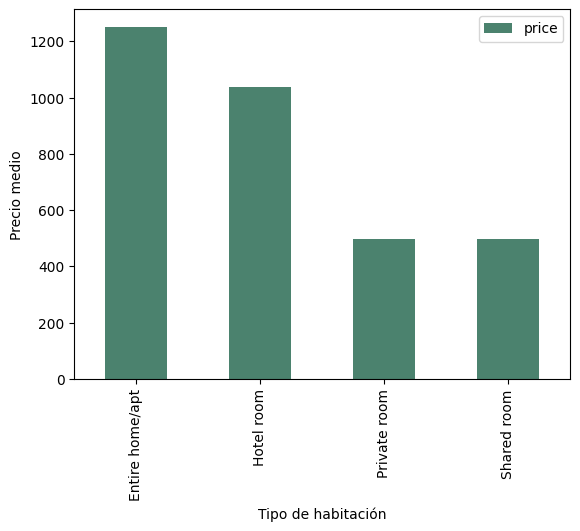

In [7]:

# Grafico importe medio por romm type
df.groupby('room_type')[['price']].mean().sort_values(by='price',ascending=False).plot.bar(color='#4b826e')
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio medio")

## Cliente

- Average rating general

- Average reviews per month (historical average rather than current performance)

In [8]:
# KPI 1 — Indice de Satisfacción General
avg_rating = df["review_scores_rating"].dropna().mean()

# KPI 2 — Average reviews per month
avg_reviews_month = df["reviews_per_month"].mean()

print(" KPI Experiencia del Cliente")
print("---------------------")
print(f"Avg rating (all scores): {avg_rating:.2f}")
print(f"Avg reviews per month: {avg_reviews_month:.2f}")

 KPI Experiencia del Cliente
---------------------
Avg rating (all scores): 91.91
Avg reviews per month: 123.53


In [9]:
satisfaction_items = {
    "accuracy": df["review_scores_accuracy"].mean(),
    "cleanliness": df["review_scores_cleanliness"].mean(),
    "checkin": df["review_scores_checkin"].mean(),
    "communication": df["review_scores_communication"].mean(),
    "location": df["review_scores_location"].mean()
}

#  dataframe
satisfaction_df = pd.DataFrame.from_dict(
    satisfaction_items,
    orient="index",
    columns=["avg_score"]
).round(2)

# Ítem con mayor satisfacción
max_item = satisfaction_df["avg_score"].idxmax()
max_value = satisfaction_df["avg_score"].max()

print("Ítem con mayor satisfacción:")
print(max_item, round(max_value,2))

print("\nAverage satisfaction by item:")
print(satisfaction_df)

Ítem con mayor satisfacción:
checkin 96.23

Average satisfaction by item:
               avg_score
accuracy           94.49
cleanliness        93.11
checkin            96.23
communication      96.21
location           95.43


## Operaciones
- Tasa de ocupación mensual
- Ciudad con mayor ocupación (mensual)

#### Preparación del dataset

In [10]:
df_operaciones = df.copy()

availability_cols = [
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365"
]

# apartamentos totalmente ocupados
df_operaciones["fully_booked"] = (df_operaciones[availability_cols] == 0).all(axis=1)


#### Variables derivadas (ocupación)

In [11]:
df_operaciones["occ_30"] = (30 - df_operaciones["availability_30"]) / 30
df_operaciones["occ_60"] = (60 - df_operaciones["availability_60"]) / 60
df_operaciones["occ_90"] = (90 - df_operaciones["availability_90"]) / 90
df_operaciones["occ_365"] = (365 - df_operaciones["availability_365"]) / 365

occupancy_cols = ["occ_30", "occ_60", "occ_90", "occ_365"]

# días ocupados (para KPI principal)
df_operaciones["occupied_days_30"] = 30 - df_operaciones["availability_30"]

#### KPI globales operaciones

In [12]:
# inventario total
total_apartments = df_operaciones["apartment_id"].nunique()

# alojamientos con disponibilidad en próximos 30 días
available_30 = (df_operaciones["availability_30"] > 0).sum()

# ratio de oferta disponible
available_supply_ratio = round((available_30 / active_apartments) * 100, 2)

# apartamentos completamente reservados
fully_booked_active = df_operaciones[
    (df_operaciones["fully_booked"]) &
    (df_operaciones["has_availability"])
].shape[0]

# ocupación promedio por horizonte temporal
occupancy_rates = (df_operaciones[occupancy_cols].mean() * 100).round(2)

#### KPI por segmento

In [13]:
# ocupación por ciudad
occupancy_by_city = (
    df_operaciones
    .groupby("city")[occupancy_cols]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

# ciudad con mayor ocupación mensual
top_city = (
    occupancy_by_city
    .sort_values("occ_30", ascending=False)
    .iloc[0]
)

# oferta disponible por ciudad
supply_by_city = (
    df_operaciones[df_operaciones["availability_30"] > 0]
    .groupby("city")["apartment_id"]
    .nunique()
    .reset_index(name="available_listings")
    .sort_values(by="available_listings", ascending=False)
)

# oferta disponible por tipo de habitación
supply_by_room = (
    df_operaciones[df_operaciones["availability_30"] > 0]
    .groupby("room_type")["apartment_id"]
    .nunique()
    .reset_index(name="available_listings")
    .sort_values(by="available_listings", ascending=False)
)

# catálogo no disponible actual
not_available = total_apartments - active_apartments
not_available_pct = round((not_available / total_apartments) * 100, 2)

# semana pasada
prev_total = 6615
prev_active = 6087

prev_not_available = prev_total - prev_active
prev_not_available_pct = round((prev_not_available / prev_total) * 100, 2)

print("No disponible actual:", not_available, f"({not_available_pct}%)")
print("No disponible antes:", prev_not_available, f"({prev_not_available_pct}%)")


No disponible actual: 534 (5.53%)
No disponible antes: 528 (7.98%)


#### Tabla final de KPI operaciones

In [14]:
kpi_operaciones = {
    "total_apartments": int(total_apartments),
    "active_apartments": int(active_apartments),
    "available_next_30_days": int(available_30),
    "available_supply_%": float(available_supply_ratio),
    "fully_booked_active": int(fully_booked_active),
    "monthly_occupancy_%": float(monthly_occupancy_rate),
    "yearly_occupancy_%": float(occupancy_rates["occ_365"]),
    "top_city_by_occupancy": top_city["city"],
    "top_city_occupancy_%": float(top_city["occ_30"])
}

kpi_operaciones_df = pd.DataFrame(
    list(kpi_operaciones.items()),
    columns=["KPI", "Valor"]
)

kpi_operaciones_df

,KPI,Valor
0,total_apartments,9650
1,active_apartments,9116
2,available_next_30_days,6848
3,available_supply_%,75.12
4,fully_booked_active,1156
5,monthly_occupancy_%,59.99
6,yearly_occupancy_%,48.61
7,top_city_by_occupancy,Madrid
8,top_city_occupancy_%,60.89


In [15]:
# Agrupación por ciudad
summary_city = df.groupby("city")["minimum_nights"].agg(
    media="mean",
    mediana="median",
    minimo="min",
    maximo="max",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    count="count"
).reset_index()

summary_city.sort_values(by="media", ascending=False)

,city,media,mediana,minimo,maximo,p25,p75,count
0,Barcelona,6.992277,2.0,1,300,1.0,3.0,2719
2,Madrid,5.038894,2.0,1,1125,1.0,3.0,2134
4,Mallorca,4.284902,4.0,1,180,1.0,6.0,1583
3,Malaga,4.224206,2.0,1,500,1.0,3.0,504
5,Menorca,4.018349,4.0,1,14,1.0,6.0,218
7,Valencia,3.686160,2.0,1,180,1.0,3.0,513
1,Girona,3.364310,2.0,1,120,1.0,5.0,1485
6,Sevilla,3.076923,2.0,1,61,1.0,2.0,494


In [17]:
# ejemplo: crear variable si no la tienes
ciudades = ["Madrid", "Barcelona", "Valencia", "Sevilla"]

df["tipo_destino"] = df["city"].apply(
    lambda x: "ciudad" if x in ciudades else "vacacional"
)

summary_tipo = df.groupby("tipo_destino")["minimum_nights"].agg(
    media="mean",
    mediana="median",
    minimo="min",
    maximo="max",
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    count="count"
).reset_index()

summary_tipo

,tipo_destino,media,mediana,minimo,maximo,p25,p75,count
0,ciudad,5.661433,2.0,1,1125,1.0,3.0,5860
1,vacacional,3.900792,3.0,1,500,1.0,5.0,3790
